# DeepWalk/Node2Vec-Style Embeddings for Contig Binning

An unsupervised random-walk graph-embedding baseline. Walk embeddings are concatenated with the RepBin-like node feature matrix before marker-derived KMeans clustering.

This notebook runs the test dataset 10 times with different seeds, records all metrics for every run, prints min/max/mean/std, and plots mean metric values with standard-deviation error bars. Labels are used only after clustering to evaluate the bins. The shared loader uses `agtools.assemblers.spades.get_contig_graph` to load `tests/data/assembly_graph_with_scaffolds.gfa`, `tests/data/contigs.fasta`, and `tests/data/contigs.paths`. Node features follow the requested RepBin-like representation: the contig adjacency-matrix row plus 136 reverse-complement-collapsed normalized tetranucleotide frequencies plus z-scored `log1p` coverage parsed from SPAdes contig IDs. The number of clusters is estimated from `contigs.fasta.markers`.

If dependencies are missing in a fresh environment, run:

```python
%pip install agtools torch scikit-learn biopython numpy pandas matplotlib
```

In [1]:
from pathlib import Path
import sys

NOTEBOOK_DIR = Path.cwd()
if NOTEBOOK_DIR.name == 'notebooks':
    REPO_ROOT = NOTEBOOK_DIR.parent
else:
    REPO_ROOT = NOTEBOOK_DIR
sys.path.insert(0, str(REPO_ROOT / 'notebooks'))

from graph_binning_common import *

DATA_DIR = REPO_ROOT / 'tests' / 'data'
SEED = 7
N_RUNS = 10
set_seed(SEED)


In [2]:
data = load_spades_dataset(DATA_DIR)
print_dataset_summary(data)

features = data['features']
adjacency = data['adjacency']
marker_pairs = data['marker_pairs']
labels = data['labels']
label_names = data['label_names']

# RepBin derives the expected number of bins from marker-gene constraints.
# Ground truth is used only after clustering to evaluate the predicted bins.
N_CLUSTERS = data['marker_cluster_count']
print(f'k for clustering from marker genes: {N_CLUSTERS}')
print(f'marker cannot-link pairs: {len(marker_pairs)}')
print(data['feature_names'][:3], '...', data['feature_names'][-3:])


contigs: 509
edges: 1033
features: 646 (509 adjacency + 136 TNF + coverage)
marker sets: 91
marker-derived k: 5
Acetobacter_pasteurianus: 118
Aeromonas_veronii: 72
Amycolatopsis_mediterranei: 105
Arthrobacter_arilaitensis: 195
Azorhizobium_caulinodans: 19
k for clustering from marker genes: 5
marker cannot-link pairs: 1820
['adjacency_to_node_0', 'adjacency_to_node_1', 'adjacency_to_node_2'] ... ['TGCA', 'TTAA', 'log1p_coverage_zscore']


In [3]:
METHOD_NAME = 'DeepWalk/Node2Vec-style PPMI'

def run_once(seed):
    set_seed(seed)
    walk_embeddings = ppmi_deepwalk_embeddings(
        adjacency,
        dimensions=32,
        walk_length=24,
        walks_per_node=16,
        window_size=5,
        seed=seed,
    )
    embeddings = np.hstack([walk_embeddings, features])
    predictions, metrics = run_kmeans(embeddings, labels, seed=seed, n_clusters=N_CLUSTERS)
    return metrics


run 01 seed=7: precision=0.9509, recall=0.8173, f1=0.8790, ari=0.7431, nmi=0.8462
run 02 seed=8: precision=0.9489, recall=0.8468, f1=0.8949, ari=0.7540, nmi=0.8402
run 03 seed=9: precision=0.9450, recall=0.8861, f1=0.9146, ari=0.7938, nmi=0.8430
run 04 seed=10: precision=0.9470, recall=0.8743, f1=0.9092, ari=0.7809, nmi=0.8427
run 05 seed=11: precision=0.9450, recall=0.8821, f1=0.9125, ari=0.7884, nmi=0.8412
run 06 seed=12: precision=0.9470, recall=0.9096, f1=0.9279, ari=0.8297, nmi=0.8645
run 07 seed=13: precision=0.9430, recall=0.8762, f1=0.9084, ari=0.7811, nmi=0.8371
run 08 seed=14: precision=0.9430, recall=0.8350, f1=0.8857, ari=0.7351, nmi=0.8185
run 09 seed=15: precision=0.9450, recall=0.8546, f1=0.8975, ari=0.7556, nmi=0.8307
run 10 seed=16: precision=0.9470, recall=0.8939, f1=0.9197, ari=0.8061, nmi=0.8505


,run,seed,precision,recall,f1,ari,nmi,n_bins_predicted,n_true_bins,aligned_macro_f1
0,1,7,0.950884,0.817289,0.879040,0.743106,0.846164,5,5,0.713275
1,2,8,0.948919,0.846758,0.894933,0.754006,0.840225,5,5,0.811156
2,3,9,0.944990,0.886051,0.914572,0.793818,0.843011,5,5,0.838712
3,4,10,0.946955,0.874263,0.909158,0.780862,0.842735,5,5,0.829995
4,5,11,0.944990,0.882122,0.912474,0.788419,0.841201,5,5,0.835689
5,6,12,0.946955,0.909627,0.927916,0.829727,0.864501,5,5,0.861524
6,7,13,0.943026,0.876228,0.908400,0.781082,0.837146,5,5,0.830837
7,8,14,0.943026,0.834971,0.885715,0.735082,0.818544,5,5,0.801549
8,9,15,0.944990,0.854617,0.897534,0.755569,0.830676,5,5,0.815788
9,10,16,0.946955,0.893910,0.919668,0.806141,0.850536,5,5,0.845141


,min,max,mean,std
precision,0.943026,0.950884,0.946169,0.002485
recall,0.817289,0.909627,0.867583,0.028533
f1,0.879040,0.927916,0.904941,0.015346
ari,0.735082,0.829727,0.776781,0.029754
nmi,0.818544,0.864501,0.841474,0.012023
aligned_macro_f1,0.713275,0.861524,0.818367,0.040784


<Axes: title={'center': 'DeepWalk/Node2Vec-style PPMI: mean metrics over 10 runs'}, ylabel='score'>

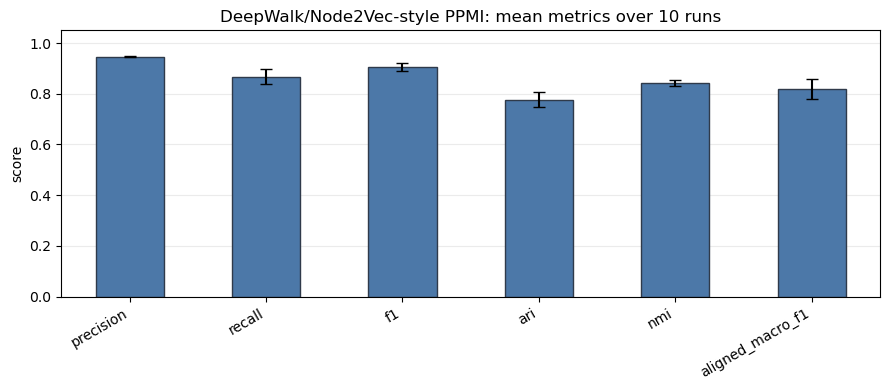

In [4]:
results = run_repeated_experiment(run_once, n_runs=N_RUNS, seed=SEED)
summary = summarize_metric_table(results)

display(results)
display(summary)
plot_metric_bars(summary, title=f'{METHOD_NAME}: mean metrics over {N_RUNS} runs')


## Assembly graph coloured by predicted bin

This plot reruns the method once on the original test graph using `SEED`, captures that method's KMeans bin assignments, and colours contigs in the igraph assembly graph by the predicted bin.

{'precision': 0.9508840864440079, 'recall': 0.8172888015717092, 'f1': 0.879039511023794, 'ari': 0.7431057273719058, 'nmi': 0.8461642586807445, 'n_bins_predicted': 5, 'n_true_bins': 5, 'aligned_macro_f1': 0.7132749469670119}
DeepWalk/Node2Vec-style PPMI: assembly graph coloured by predicted bin
bin 0: 116 contigs
bin 1: 102 contigs
bin 2: 93 contigs
bin 3: 90 contigs
bin 4: 108 contigs


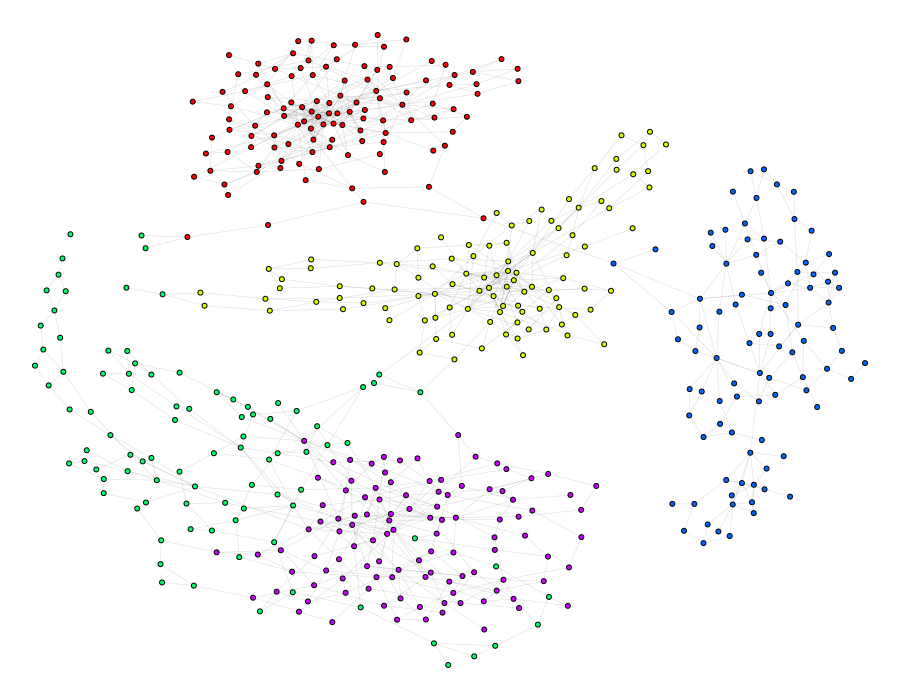

In [5]:
_visual_predictions = None
_original_run_kmeans = run_kmeans

def _capture_run_kmeans(embeddings, labels, seed=7, n_clusters=None):
    global _visual_predictions
    predictions, metrics = _original_run_kmeans(embeddings, labels, seed=seed, n_clusters=n_clusters)
    _visual_predictions = predictions
    return predictions, metrics

run_kmeans = _capture_run_kmeans
try:
    visual_metrics = run_once(SEED)
finally:
    run_kmeans = _original_run_kmeans

print(visual_metrics)
plot_assembly_graph_bins(
    data,
    bins=_visual_predictions,
    title=f'{METHOD_NAME}: assembly graph coloured by predicted bin',
)


## Graph corruption / ablation study

This section reruns the same method under five graph conditions: original assembly graph, random edge removal, random edge addition, coverage-similarity edges added, and short contigs removed. Each condition is run with the same 10 seeds, then metrics are summarized and plotted with standard-deviation error bars.

ablation: original assembly graph
ablation: random edge removal
ablation: random edge addition
ablation: coverage-similarity edges added
ablation: short contigs removed


,ablation,run,seed,precision,recall,f1,ari,nmi,n_bins_predicted,n_true_bins,aligned_macro_f1
0,original assembly graph,1,7,0.950884,0.817289,0.879040,0.743106,0.846164,5,5,0.713275
1,original assembly graph,2,8,0.948919,0.846758,0.894933,0.754006,0.840225,5,5,0.811156
2,original assembly graph,3,9,0.944990,0.886051,0.914572,0.793818,0.843011,5,5,0.838712
3,original assembly graph,4,10,0.946955,0.874263,0.909158,0.780862,0.842735,5,5,0.829995
4,original assembly graph,5,11,0.944990,0.882122,0.912474,0.788419,0.841201,5,5,0.835689
5,original assembly graph,6,12,0.946955,0.909627,0.927916,0.829727,0.864501,5,5,0.861524
6,original assembly graph,7,13,0.943026,0.876228,0.908400,0.781082,0.837146,5,5,0.830837
7,original assembly graph,8,14,0.943026,0.834971,0.885715,0.735082,0.818544,5,5,0.801549
8,original assembly graph,9,15,0.944990,0.854617,0.897534,0.755569,0.830676,5,5,0.815788
9,original assembly graph,10,16,0.946955,0.893910,0.919668,0.806141,0.850536,5,5,0.845141


precision                                \
                                      min       max      mean       std   
ablation                                                                  
original assembly graph          0.943026  0.950884  0.946169  0.002485   
random edge removal              0.913556  0.921415  0.918468  0.003617   
random edge addition             0.866405  0.901768  0.890766  0.012467   
coverage-similarity edges added  0.807466  0.846758  0.828094  0.014592   
short contigs removed            0.935556  0.940000  0.937333  0.001753   

                                   recall                                \
                                      min       max      mean       std   
ablation                                                                  
original assembly graph          0.817289  0.909627  0.867583  0.028533   
random edge removal              0.795678  0.817289  0.805894  0.007513   
random edge addition             0.783890  0.870334  0.810806  0.024293   
coverage-similarity edges added  0.728880  0.840864  0.797053  0.041253   
short contigs removed            0.826667  0.833333  0.830667  0.002295   

                                       f1            ...       ari            \
                                      min       max  ...      mean       std   
ablation                                             ...                       
original assembly graph          0.879040  0.927916  ...  0.776781  0.029754   
random edge removal              0.851673  0.866234  ...  0.684488  0.007965   
random edge addition             0.833573  0.870334  ...  0.646069  0.021079   
coverage-similarity edges added  0.778327  0.843801  ...  0.582287  0.047356   
short contigs removed            0.877747  0.883459  ...  0.737465  0.004096   

                                      nmi                                \
                                      min       max      mean       std   
ablation                                                                  
original assembly graph          0.818544  0.864501  0.841474  0.012023   
random edge removal              0.761785  0.779655  0.771777  0.005640   
random edge addition             0.682976  0.718511  0.705013  0.012134   
coverage-similarity edges added  0.591248  0.665471  0.621626  0.026563   
short contigs removed            0.809319  0.824849  0.816347  0.005803   

                                aligned_macro_f1                                
                                             min       max      mean       std  
ablation                                                                        
original assembly graph                 0.713275  0.861524  0.818367  0.040784  
random edge removal                     0.769849  0.785782  0.778100  0.004903  
random edge addition                    0.753101  0.840519  0.776215  0.024729  
coverage-similarity edges added         0.631484  0.815002  0.709386  0.082183  
short contigs removed                   0.793067  0.798592  0.796142  0.001968  

[5 rows x 24 columns]

<Axes: title={'center': 'DeepWalk/Node2Vec-style PPMI: graph corruption / ablation study'}, xlabel='ablation', ylabel='score'>

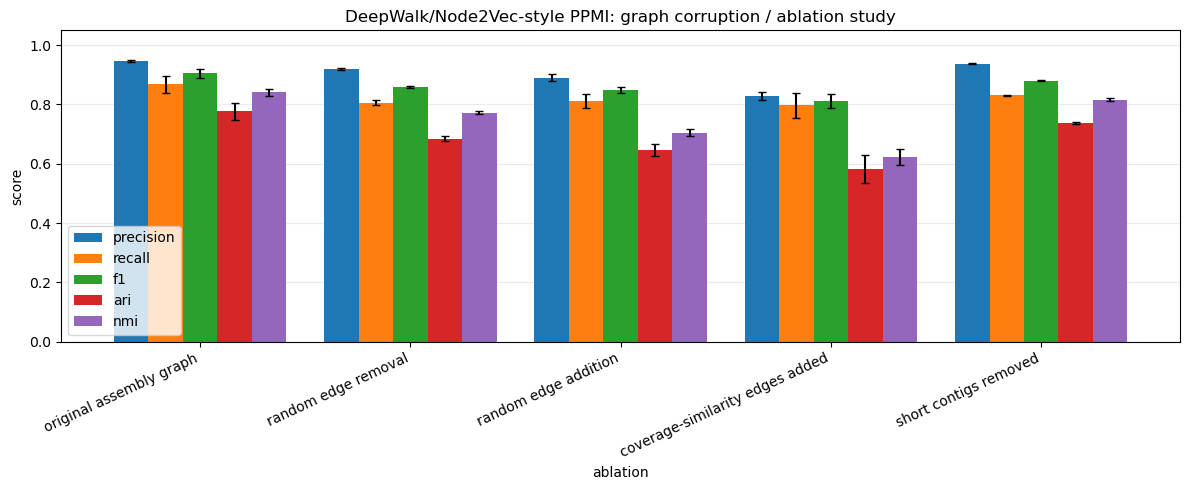

In [6]:
def run_once_ablation(seed, ablation_data):
    global features, adjacency, marker_pairs, labels, label_names, N_CLUSTERS, spectral_embeddings

    old_state = {
        'features': features,
        'adjacency': adjacency,
        'marker_pairs': marker_pairs,
        'labels': labels,
        'label_names': label_names,
        'N_CLUSTERS': N_CLUSTERS,
        'spectral_embeddings': globals().get('spectral_embeddings', None),
    }
    try:
        features = ablation_data['features']
        adjacency = ablation_data['adjacency']
        marker_pairs = ablation_data['marker_pairs']
        labels = ablation_data['labels']
        label_names = ablation_data['label_names']
        N_CLUSTERS = ablation_data['marker_cluster_count']

        # The Laplacian Eigenmaps notebook precomputes graph embeddings outside
        # run_once, so recompute them when the graph changes.
        if 'laplacian_eigenmap_embeddings' in globals():
            spectral_embeddings = laplacian_eigenmap_embeddings(adjacency, dimensions=32)

        return run_once(seed)
    finally:
        features = old_state['features']
        adjacency = old_state['adjacency']
        marker_pairs = old_state['marker_pairs']
        labels = old_state['labels']
        label_names = old_state['label_names']
        N_CLUSTERS = old_state['N_CLUSTERS']
        if old_state['spectral_embeddings'] is not None:
            spectral_embeddings = old_state['spectral_embeddings']

ablation_results, ablation_summary = run_graph_ablation_study(
    data,
    run_once_ablation,
    n_runs=N_RUNS,
    seed=SEED,
)

display(ablation_results)
display(ablation_summary)
plot_ablation_metric_bars(ablation_summary, title=f'{METHOD_NAME}: graph corruption / ablation study')
